In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_path = Path(r"C:\Users\rohit\OneDrive\Documents\My_personal\projects\Agriculture-ML-Based Attack Detection\notebooks\data\raw_data\Smart-Farm-IDS.csv")
df = pd.read_csv(data_path)

In [4]:
df.head()

,Timestamp,WaterLevel,WaterPumpToTank,WaterPumpFromTank,WaterTemperature,Ec,Tds,LightIntensity,Humidity,Temperature,HeatIndex,AirQuality,SoilHumidity1,SoilHumidity2,Light,Class
0,14.6.2024 2:0:0,9,Inactive,Inactive,25.88,688.67,256,592.50,58.5,27.3,22.48,476,11.53,13.39,On,Normal
1,14.6.2024 2:0:1,9,Inactive,Inactive,25.88,688.67,256,595.00,58.6,27.3,22.48,475,11.53,13.49,On,Normal
2,14.6.2024 2:0:2,9,Inactive,Inactive,25.88,688.67,256,595.83,58.6,27.3,22.48,476,11.53,13.49,On,Normal
3,14.6.2024 2:0:3,9,Inactive,Inactive,25.88,688.67,256,595.00,58.6,27.3,22.49,475,11.34,13.59,On,Normal
4,14.6.2024 2:0:4,9,Inactive,Inactive,25.88,688.67,256,594.17,58.6,27.3,22.49,475,11.53,13.49,On,Normal


In [5]:
df.shape

(172800, 16)

In [6]:
df.columns

Index(['Timestamp', 'WaterLevel', 'WaterPumpToTank', 'WaterPumpFromTank',
       'WaterTemperature', 'Ec', 'Tds', 'LightIntensity', 'Humidity',
       'Temperature', 'HeatIndex', 'AirQuality', 'SoilHumidity1',
       'SoilHumidity2', 'Light', 'Class'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 172800 entries, 0 to 172799
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Timestamp          172800 non-null  str    
 1   WaterLevel         172800 non-null  int64  
 2   WaterPumpToTank    172800 non-null  str    
 3   WaterPumpFromTank  172800 non-null  str    
 4   WaterTemperature   172800 non-null  float64
 5   Ec                 172800 non-null  float64
 6   Tds                172800 non-null  int64  
 7   LightIntensity     172800 non-null  float64
 8   Humidity           172800 non-null  float64
 9   Temperature        172800 non-null  float64
 10  HeatIndex          172800 non-null  float64
 11  AirQuality         172800 non-null  int64  
 12  SoilHumidity1      172800 non-null  float64
 13  SoilHumidity2      172800 non-null  float64
 14  Light              172800 non-null  str    
 15  Class              172800 non-null  str    
dtypes: float64(8)

Basic Understanding : 

From Above functions we can conclude that we have (172800 rows , 16 columns )  and the where categorical 5 and numerical 11

Timestamp and WaterPumpToTank and WaterPumpFromTank and Light and Class are string type 

WaterLevel , Tds , AirQuality are int type

WaterTemperature, Ec, LightIntensity, Humidity, Temperature, HeatIndex, SoilHumidity1, SoilHumidity2 are float type

Timestamp: Time when the sensor reading was recorded.

WaterLevel: Amount of water in the tank.

WaterPumpToTank: Status of the pump filling the tank.

WaterPumpFromTank: Status of the pump supplying water to plants.

WaterTemperature: Temperature of the water in the tank.

EC (Electrical Conductivity): Measure of nutrient concentration in water.

TDS (Total Dissolved Solids): Total dissolved minerals and salts in water.

LightIntensity: Amount of light reaching the system.

Humidity: Moisture level in the air.

Temperature: Surrounding air temperature.

HeatIndex: Feels-like temperature based on heat and humidity.

AirQuality: Level of air cleanliness or pollution.

SoilHumidity1: Moisture level in soil zone 1.

SoilHumidity2: Moisture level in soil zone 2.

Light: Status of the grow lights.

Data Quality Check

In [8]:
df.isnull().sum()


Timestamp            0
WaterLevel           0
WaterPumpToTank      0
WaterPumpFromTank    0
WaterTemperature     0
Ec                   0
Tds                  0
LightIntensity       0
Humidity             0
Temperature          0
HeatIndex            0
AirQuality           0
SoilHumidity1        0
SoilHumidity2        0
Light                0
Class                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().mean()*100

Timestamp            0.0
WaterLevel           0.0
WaterPumpToTank      0.0
WaterPumpFromTank    0.0
WaterTemperature     0.0
Ec                   0.0
Tds                  0.0
LightIntensity       0.0
Humidity             0.0
Temperature          0.0
HeatIndex            0.0
AirQuality           0.0
SoilHumidity1        0.0
SoilHumidity2        0.0
Light                0.0
Class                0.0
dtype: float64

from above conclustion we dont have any missing value or duplicate values 

Statistical Summary : 

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
WaterLevel,172800.0,12.479022,5.200186,0.00,9.00,9.00,20.00,25.00
WaterTemperature,172800.0,27.319860,1.368934,0.00,26.63,27.38,27.75,44.04
Ec,172800.0,741.212092,85.666559,0.00,671.88,697.07,848.24,940.63
Tds,172800.0,276.681916,48.609815,0.00,250.00,259.00,312.00,883.00
LightIntensity,172800.0,602.477701,348.797700,11.10,259.17,606.67,889.17,1721.67
Humidity,172800.0,62.122519,5.032033,51.90,58.60,60.40,68.00,71.70
Temperature,172800.0,28.525834,1.389087,0.00,28.10,28.70,29.00,30.10
HeatIndex,172800.0,24.065455,1.343500,2.20,23.46,24.34,24.86,31.09
AirQuality,172800.0,457.355966,57.011055,345.00,418.00,441.00,479.00,641.00
SoilHumidity1,172800.0,14.713070,6.600859,5.56,9.90,11.34,23.46,34.02


In [12]:
df.describe(include='object').T  # for categorical features 

C:\Users\rohit\AppData\Local\Temp\ipykernel_22676\2526076150.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T  # for categorical features


,count,unique,top,freq
Timestamp,172800,172800,14.6.2024 2:0:0,1
WaterPumpToTank,172800,2,Inactive,168471
WaterPumpFromTank,172800,2,Inactive,171046
Light,172800,2,Off,95881
Class,172800,2,Normal,156252


Conclustion of sttsistical measures : 

The dataset contains 172,800 records for all numerical features, indicating that there are no missing values in these columns. This provides a complete dataset for further analysis and model development.

The WaterLevel feature has an average value of 12.48, while the median is 9, suggesting that water levels are generally concentrated at lower values and the distribution is slightly positively skewed. Most water level readings fall between 9 and 20 units.

The WaterTemperature feature has an average of 27.32°C with a low standard deviation of 1.37, indicating that water temperature remains relatively stable. However, the minimum value of 0°C appears unrealistic for a smart agriculture environment and may represent sensor errors or invalid readings.

The Electrical Conductivity (EC) feature has an average value of 741.21 and shows moderate variability. The minimum value of 0 is suspicious because EC should normally be greater than zero in nutrient-rich water, suggesting possible sensor or data collection issues.

The Total Dissolved Solids (TDS) feature has an average of 276.68 with a maximum value of 883, which is considerably higher than the upper quartile value of 312. This indicates the presence of potential outliers or sudden increases in dissolved mineral concentration.

The LightIntensity feature exhibits the highest variability among all features, with a standard deviation of 348.80 and values ranging from 11.10 to 1721.67. This large variation likely reflects changing environmental conditions such as day-night cycles and sunlight fluctuations, making it an important feature for predictive modeling.

The Humidity feature has an average value of 62.12% and a relatively low standard deviation of 5.03, indicating that humidity levels remain fairly stable throughout the observation period.

The Temperature feature has an average of 28.53°C and shows low variability. Similar to WaterTemperature, the minimum value of 0°C appears unrealistic and should be investigated as a possible data quality issue.

The HeatIndex feature has an average value of 24.07 and generally remains stable. However, the minimum value of 2.2 is unusually low and may represent anomalous observations.

The AirQuality feature has an average value of 457.36 and moderate variability. The distribution appears relatively stable with no obvious indication of extreme outliers.

The SoilHumidity1 feature has an average value of 14.71 and a standard deviation of 6.60, indicating substantial variation in soil moisture levels. This suggests that irrigation and water availability vary over time.

The SoilHumidity2 feature has an average value of 16.95 and a standard deviation of 7.56, showing even greater variability than SoilHumidity1. This suggests differences in moisture conditions across sensor locations and may provide useful information for irrigation management.

Feature Distributions

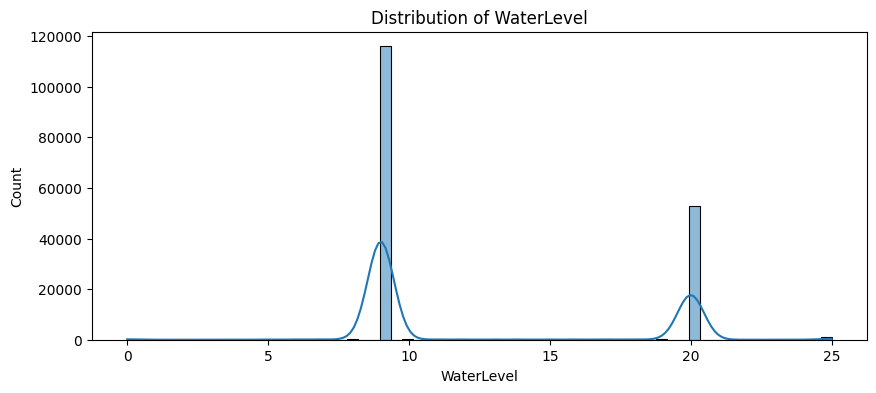

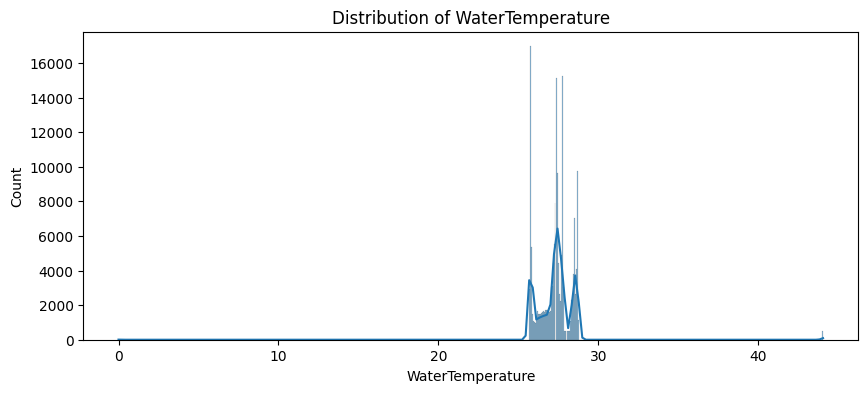

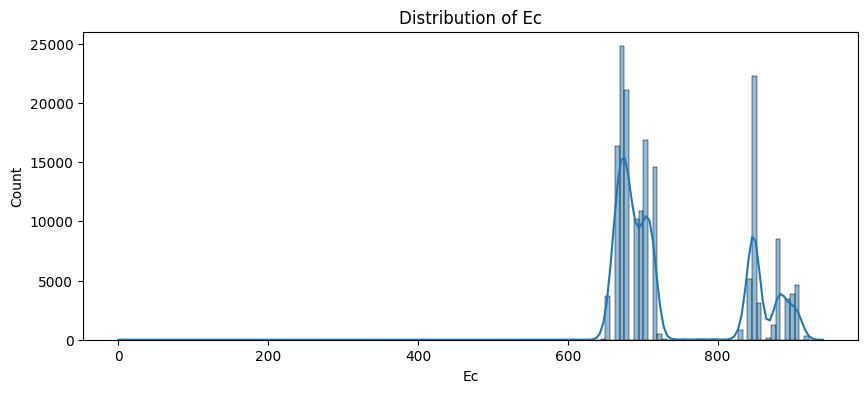

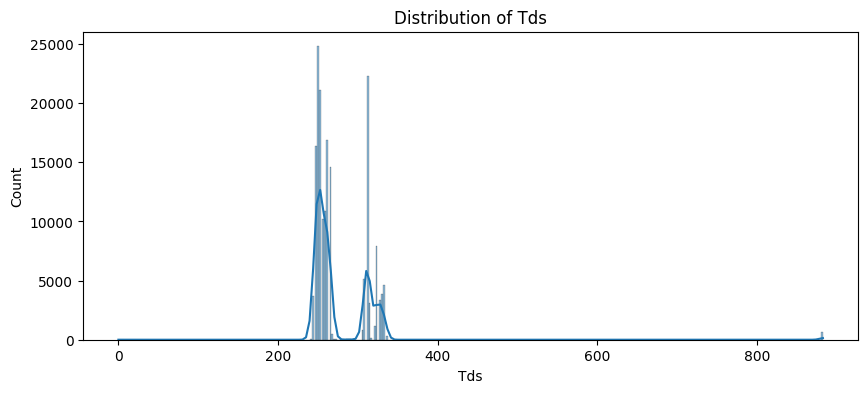

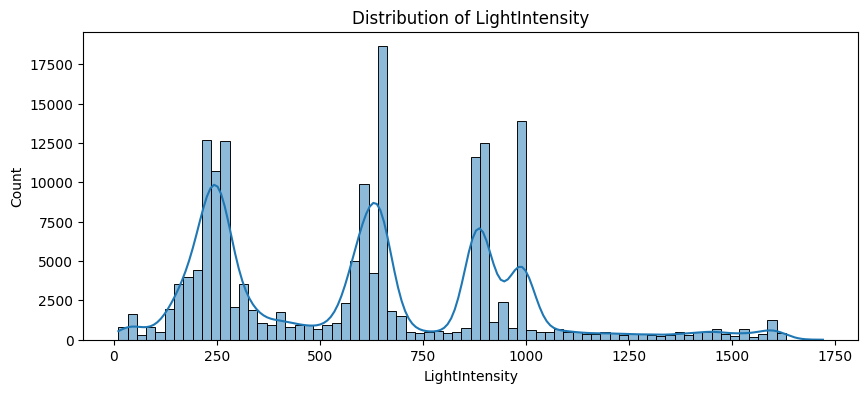

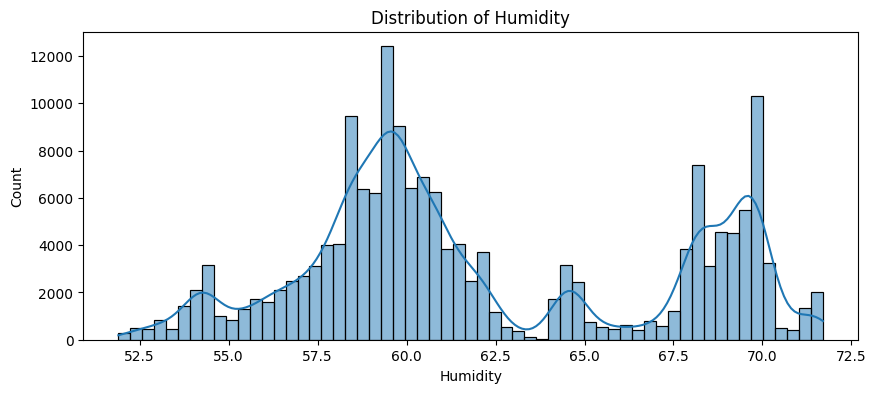

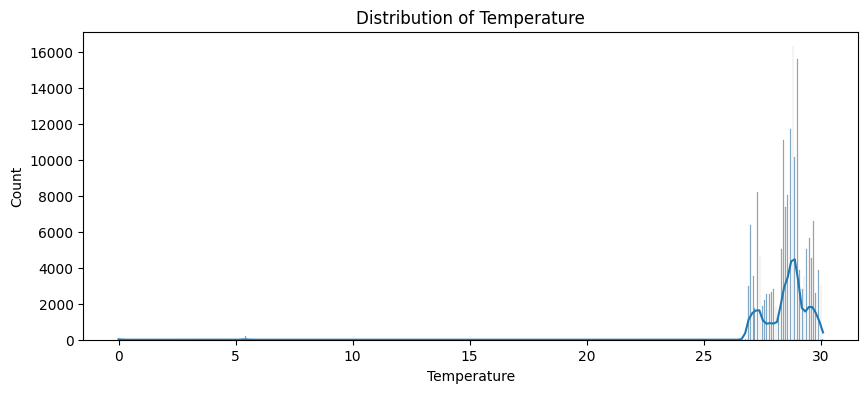

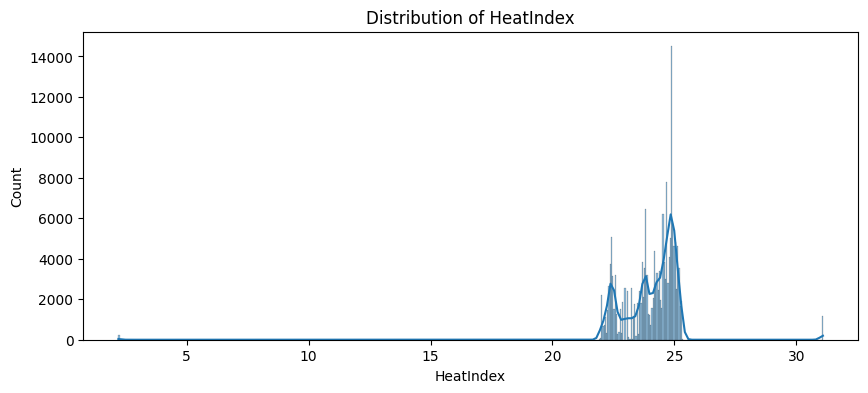

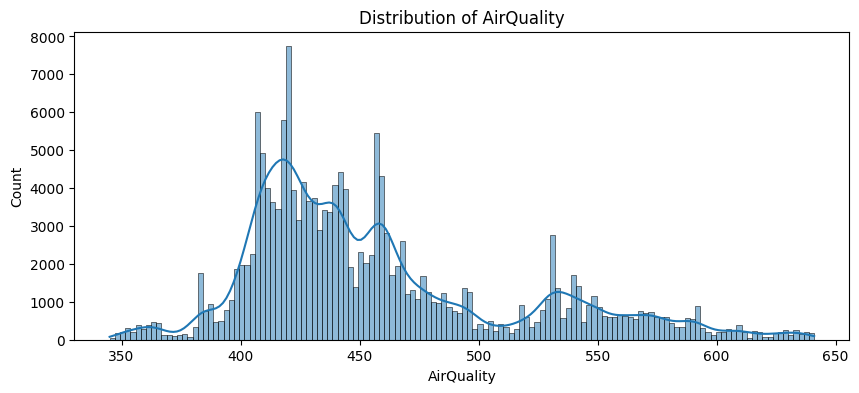

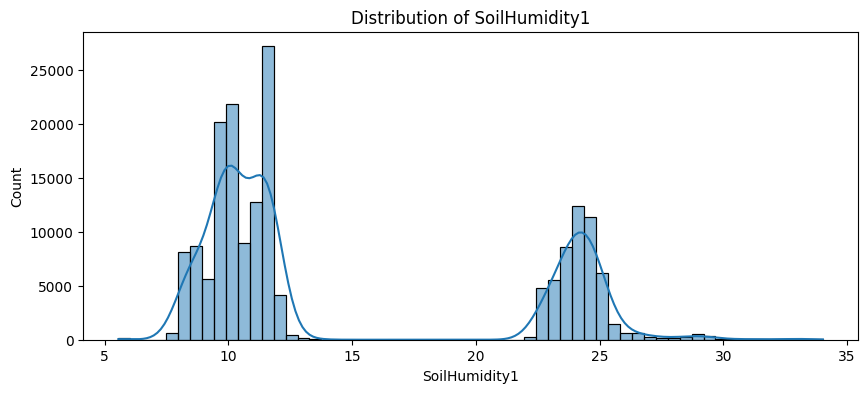

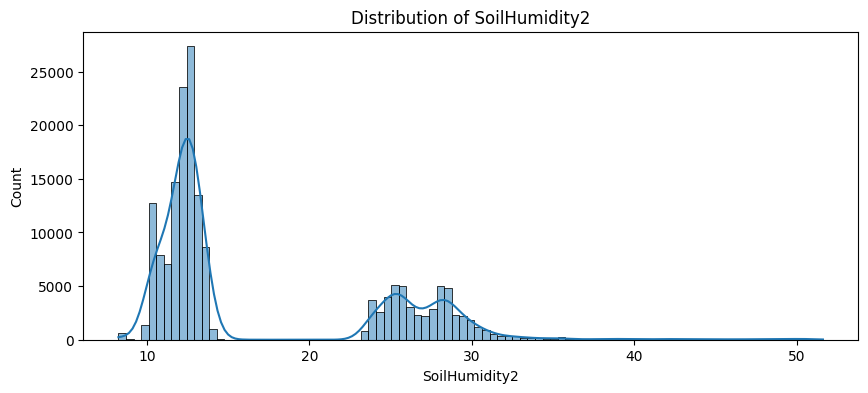

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns
for i in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[i], kde=True)
    plt.title(f"Distribution of {i}")
    plt.show()

In [14]:
new=[]
for i in numeric_cols:
    counts, bins = np.histogram(df[i], bins=10)
    print("Counts:", counts)
    print("Bins:", bins)
    new.append((i, counts, bins))

    print()

Counts: [   448     60    360 116373    511    339    510    340  52820   1039]
Bins: [ 0.   2.5  5.   7.5 10.  12.5 15.  17.5 20.  22.5 25. ]

Counts: [    41      0      0      0      0  37303 134923      0      0    533]
Bins: [ 0.     4.404  8.808 13.212 17.616 22.02  26.424 30.828 35.232 39.636
 44.04 ]

Counts: [    16      0      0      0      0      0   3785 115380   6159  47460]
Bins: [  0.     94.063 188.126 282.189 376.252 470.315 564.378 658.441 752.504
 846.567 940.63 ]

Counts: [    11      0 103993  68110      0      0      0      0      0    686]
Bins: [  0.   88.3 176.6 264.9 353.2 441.5 529.8 618.1 706.4 794.7 883. ]

Counts: [12098 49680  7688 43779  4478 43186  3717  2659  3365  2150]
Bins: [  11.1    182.157  353.214  524.271  695.328  866.385 1037.442 1208.499
 1379.556 1550.613 1721.67 ]

Counts: [ 3489 10190 15120 45853 31355  7529  8710  4799 32547 13208]
Bins: [51.9  53.88 55.86 57.84 59.82 61.8  63.78 65.76 67.74 69.72 71.7 ]

Counts: [   150    182      0   

In [15]:
print(new)

[('WaterLevel', array([   448,     60,    360, 116373,    511,    339,    510,    340,
        52820,   1039]), array([ 0. ,  2.5,  5. ,  7.5, 10. , 12.5, 15. , 17.5, 20. , 22.5, 25. ])), ('WaterTemperature', array([    41,      0,      0,      0,      0,  37303, 134923,      0,
            0,    533]), array([ 0.   ,  4.404,  8.808, 13.212, 17.616, 22.02 , 26.424, 30.828,
       35.232, 39.636, 44.04 ])), ('Ec', array([    16,      0,      0,      0,      0,      0,   3785, 115380,
         6159,  47460]), array([  0.   ,  94.063, 188.126, 282.189, 376.252, 470.315, 564.378,
       658.441, 752.504, 846.567, 940.63 ])), ('Tds', array([    11,      0, 103993,  68110,      0,      0,      0,      0,
            0,    686]), array([  0. ,  88.3, 176.6, 264.9, 353.2, 441.5, 529.8, 618.1, 706.4,
       794.7, 883. ])), ('LightIntensity', array([12098, 49680,  7688, 43779,  4478, 43186,  3717,  2659,  3365,
        2150]), array([  11.1  ,  182.157,  353.214,  524.271,  695.328,  866.385,
 

In [16]:
for i in numeric_cols:
    print(f"Skewness of {i}: {df[i].skew()}")

Skewness of WaterLevel: 0.7687516279197979
Skewness of WaterTemperature: 3.6136478002686245
Skewness of Ec: 0.7376462965630532
Skewness of Tds: 7.826258012176353
Skewness of LightIntensity: 0.5104753188558268
Skewness of Humidity: 0.3590129218576004
Skewness of Temperature: -12.4278444882625
Skewness of HeatIndex: -4.56628389839933
Skewness of AirQuality: 1.0415809946271484
Skewness of SoilHumidity1: 0.791072333665298
Skewness of SoilHumidity2: 1.1376707105883137


Distribution Analysis Conclusions
WaterLevel

The WaterLevel feature is moderately positively skewed (Skewness = 0.77). Most observations are concentrated around water levels of 9 and 20, while very few readings occur at extreme values. This indicates that the tank generally operates within a limited set of water levels.

WaterTemperature

The WaterTemperature feature is highly positively skewed (Skewness = 3.61). Most readings lie between 26°C and 30°C, but a small number of extreme values, including 0°C and 44°C, create a long right tail. These values should be investigated as possible sensor anomalies.

EC (Electrical Conductivity)

The EC feature is moderately positively skewed (Skewness = 0.74). Most observations fall within 650–900, indicating relatively stable nutrient concentrations. However, the presence of zero values suggests potential sensor or data collection errors.

TDS

The TDS feature is extremely positively skewed (Skewness = 7.83). Most observations are concentrated between 250 and 350, while a few values extend to 883. This suggests significant outliers or unusual nutrient concentration events.

🚩 Strong outlier presence detected.

LightIntensity

The LightIntensity feature is slightly positively skewed (Skewness = 0.51). The distribution shows multiple peaks, indicating different lighting conditions such as low light, moderate light, and high light periods. This suggests cyclical environmental behavior and makes LightIntensity an important predictive feature.

Humidity

The Humidity feature is approximately symmetric (Skewness = 0.36). Most observations are concentrated between 58% and 70%, indicating stable environmental humidity conditions. No major distributional issues are observed.

✅ Near-normal distribution.

Temperature

The Temperature feature exhibits extreme negative skewness (Skewness = -12.43). Almost all observations are concentrated between 27°C and 30°C, while a small number of zero values create a long left tail.

🚩 This strongly suggests invalid sensor readings or erroneous data entries.

HeatIndex

The HeatIndex feature is highly negatively skewed (Skewness = -4.57). Most observations are concentrated around 22–25, but a few unusually low values create a substantial left tail.

🚩 Potential anomalies or measurement errors exist.

AirQuality

The AirQuality feature is positively skewed (Skewness = 1.04). Most values are concentrated between 400 and 500, while a smaller number of higher readings extend the distribution toward 640. This indicates occasional periods of reduced air quality.

SoilHumidity1

The SoilHumidity1 feature is moderately positively skewed (Skewness = 0.79). The histogram shows two distinct peaks around 10–12 and 23–25, suggesting two different moisture states in the monitored area.

✅ Possible bimodal distribution.

SoilHumidity2

The SoilHumidity2 feature is highly positively skewed (Skewness = 1.14). Similar to SoilHumidity1, the distribution exhibits two clusters, indicating varying moisture conditions across different sensor locations or irrigation cycles.

✅ Possible bimodal distribution with high variability.

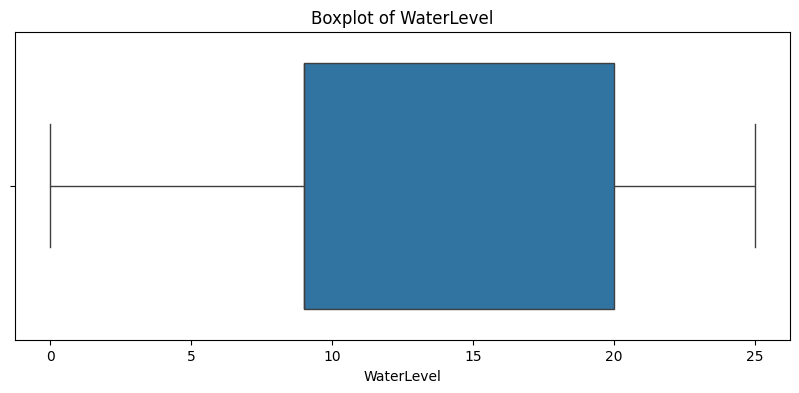

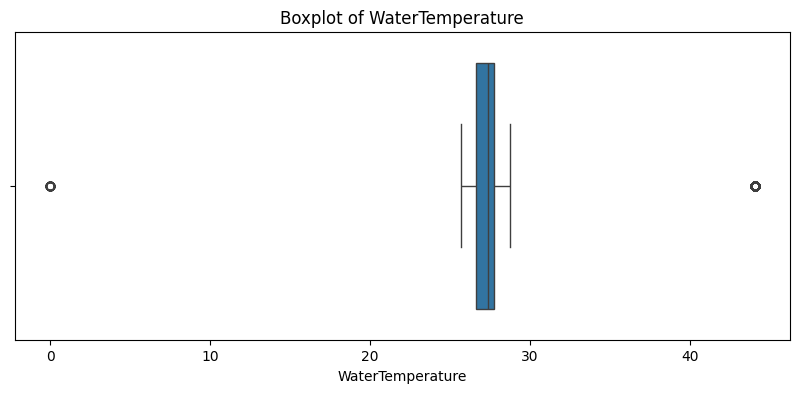

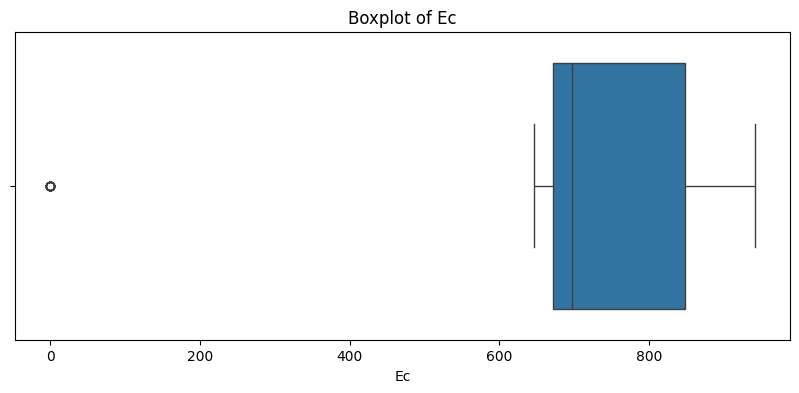

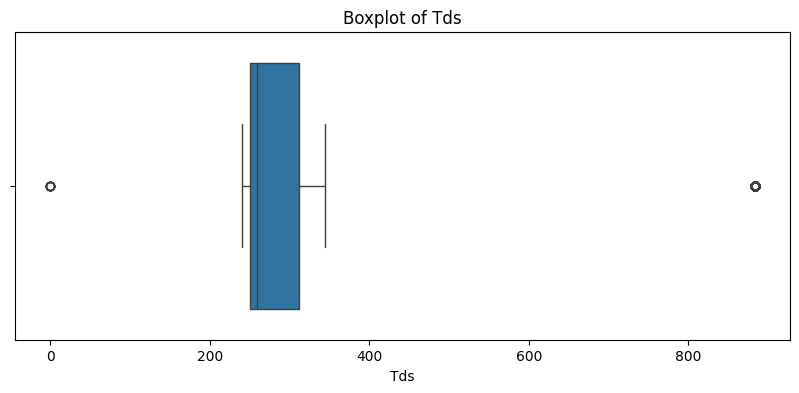

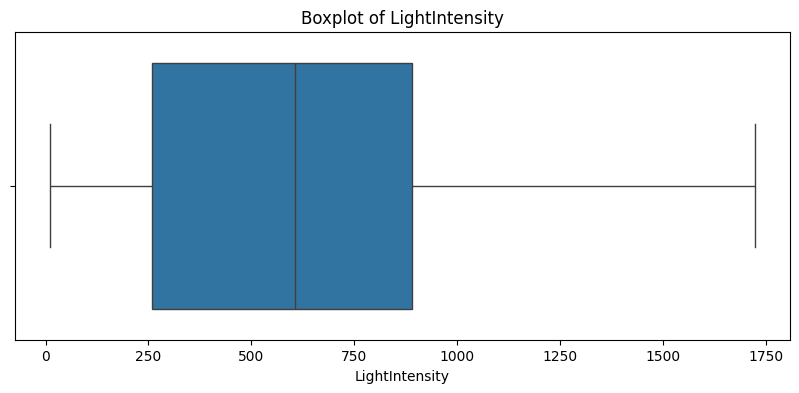

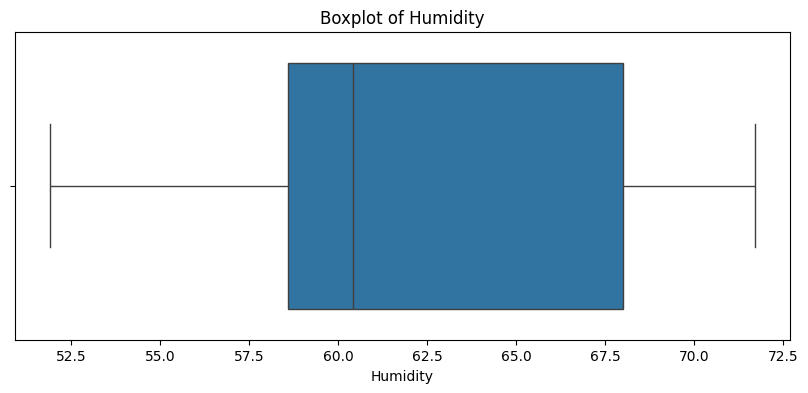

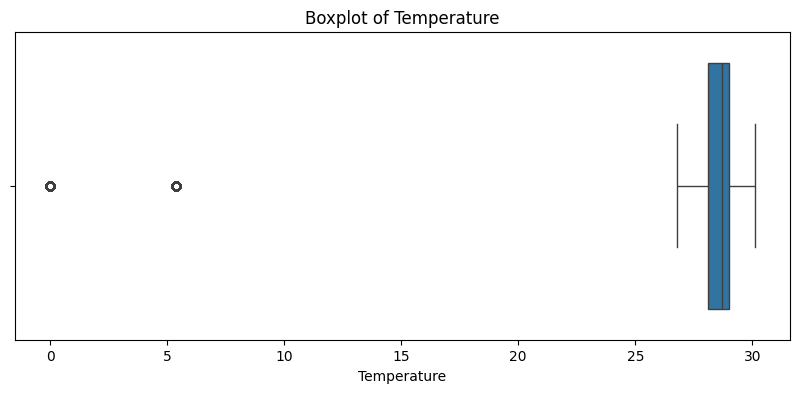

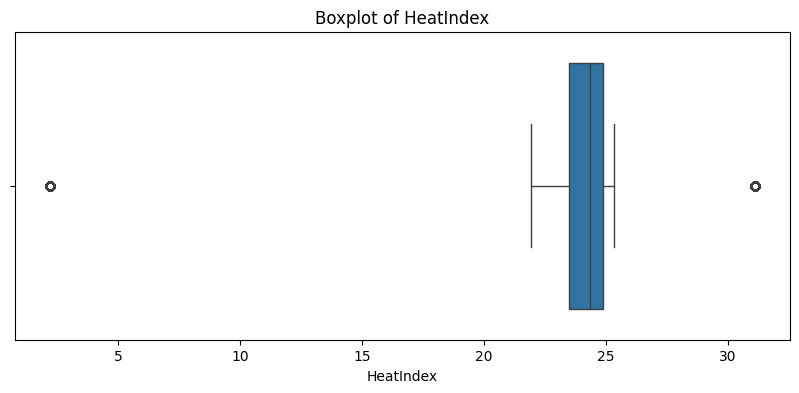

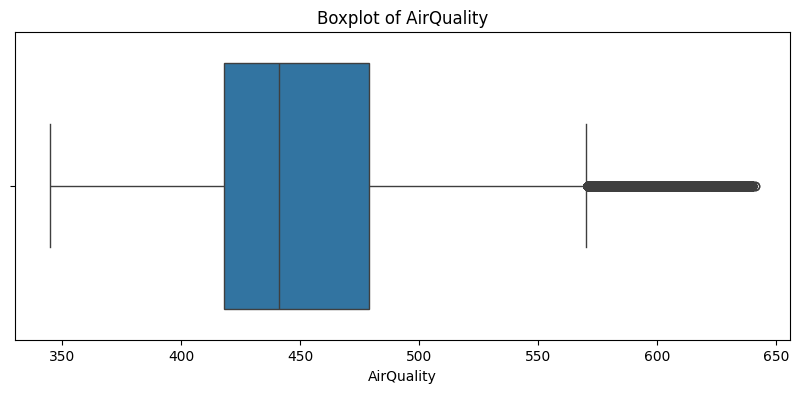

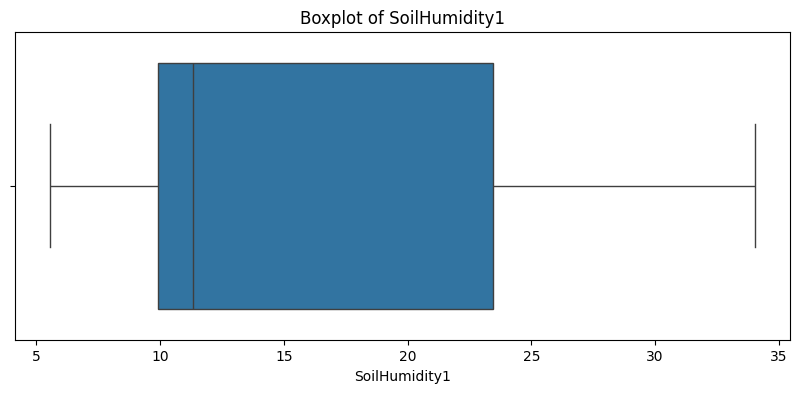

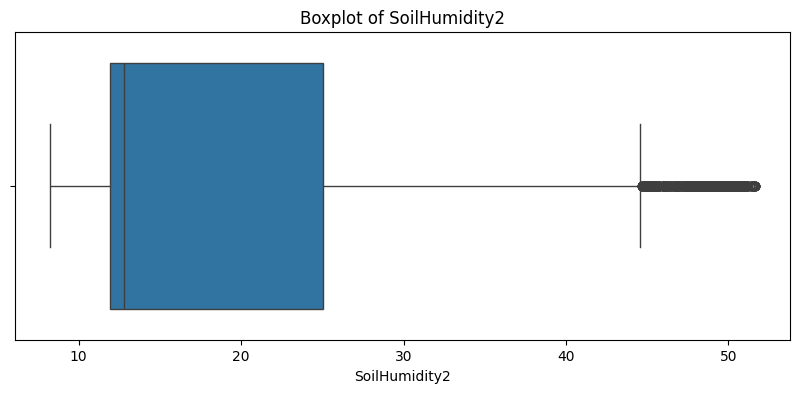

In [17]:
for i in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[i])
    plt.title(f"Boxplot of {i}")
    plt.show()

by observing the above box plot water temperature and ec, tds , temperature , head index ,and majorly airquality ahs so many outliers  and soil humidity 2 has major outliers 





The IQR analysis reveals that WaterTemperature, EC, TDS, Temperature, HeatIndex, AirQuality, and SoilHumidity2 contain outliers. Among these, Temperature, WaterTemperature, EC, and TDS exhibit suspicious zero values that may indicate sensor malfunctions, missing-value encoding, or data recording errors. In contrast, WaterLevel, LightIntensity, Humidity, and SoilHumidity1 do not contain significant outliers and appear to be well-behaved features. Before building machine learning models, the identified outliers should be validated, corrected, removed, or treated using robust preprocessing techniques.

In [18]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col)
    print("Outliers:", len(outliers))
    print("Percentage:", len(outliers)/len(df)*100)

WaterLevel
Outliers: 0
Percentage: 0.0
WaterTemperature
Outliers: 574
Percentage: 0.33217592592592593
Ec
Outliers: 16
Percentage: 0.009259259259259259
Tds
Outliers: 697
Percentage: 0.40335648148148145
LightIntensity
Outliers: 0
Percentage: 0.0
Humidity
Outliers: 0
Percentage: 0.0
Temperature
Outliers: 332
Percentage: 0.19212962962962965
HeatIndex
Outliers: 1395
Percentage: 0.8072916666666667
AirQuality
Outliers: 10316
Percentage: 5.969907407407407
SoilHumidity1
Outliers: 0
Percentage: 0.0
SoilHumidity2
Outliers: 769
Percentage: 0.44502314814814814


In [19]:
for i in numeric_cols:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_Bound = Q1 - 1.5 * IQR
    upper_Bound = Q3 + 1.5 * IQR
    print(f"interquartile Range (IQR) of {i}: {IQR}")
    print(f"lower Bound of {i}: {lower_Bound}")
    print(f"upper Bound of {i}: {upper_Bound}")

interquartile Range (IQR) of WaterLevel: 11.0
lower Bound of WaterLevel: -7.5
upper Bound of WaterLevel: 36.5
interquartile Range (IQR) of WaterTemperature: 1.120000000000001
lower Bound of WaterTemperature: 24.949999999999996
upper Bound of WaterTemperature: 29.43
interquartile Range (IQR) of Ec: 176.36
lower Bound of Ec: 407.34
upper Bound of Ec: 1112.78
interquartile Range (IQR) of Tds: 62.0
lower Bound of Tds: 157.0
upper Bound of Tds: 405.0
interquartile Range (IQR) of LightIntensity: 630.0
lower Bound of LightIntensity: -685.8299999999999
upper Bound of LightIntensity: 1834.17
interquartile Range (IQR) of Humidity: 9.399999999999999
lower Bound of Humidity: 44.5
upper Bound of Humidity: 82.1
interquartile Range (IQR) of Temperature: 0.8999999999999986
lower Bound of Temperature: 26.750000000000004
upper Bound of Temperature: 30.349999999999998
interquartile Range (IQR) of HeatIndex: 1.3999999999999986
lower Bound of HeatIndex: 21.360000000000003
upper Bound of HeatIndex: 26.95999

Class Inbalance


In [20]:
df['Class'].value_counts()

Class
Normal    156252
Attack     16548
Name: count, dtype: int64

In [21]:

df['Class'].value_counts(normalize=True)*100

Class
Normal    90.423611
Attack     9.576389
Name: proportion, dtype: float64

C:\Users\rohit\AppData\Local\Temp\ipykernel_22676\2439084081.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Class', palette='Set2')


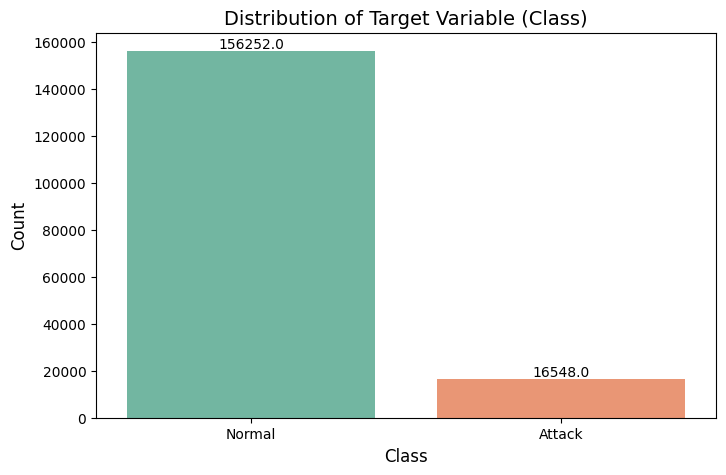

Class Distribution Percentages:
 Class
Normal    90.423611
Attack     9.576389
Name: proportion, dtype: float64


In [39]:
# Create a new cell and run this code
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Class', palette='Set2')
plt.title('Distribution of Target Variable (Class)', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

# Calculate the exact percentages
class_percentages = df['Class'].value_counts(normalize=True) * 100
print("Class Distribution Percentages:\n", class_percentages)


Class Distribution Analysis: The target variable is imbalanced, with the Normal class accounting for 90.42% of observations and the Attack class representing only 9.58%. This corresponds to an approximate class ratio of 9.4:1. Such imbalance may bias machine learning models toward the majority class, leading to poor attack detection performance. Therefore, evaluation should emphasize Precision, Recall, F1-score, and ROC-AUC rather than relying solely on accuracy.

Relationship between features

In [22]:
df.corr(numeric_only=True)

,WaterLevel,WaterTemperature,Ec,Tds,LightIntensity,Humidity,Temperature,HeatIndex,AirQuality,SoilHumidity1,SoilHumidity2
WaterLevel,1.000000,0.353992,0.928922,0.641521,0.200573,-0.066936,0.375824,0.462729,-0.363002,0.923320,0.871070
WaterTemperature,0.353992,1.000000,0.403561,0.288665,0.221209,-0.029371,0.423643,0.436850,-0.086205,0.287984,0.239994
Ec,0.928922,0.403561,1.000000,0.691240,0.307753,-0.104880,0.417460,0.512182,-0.377789,0.932932,0.871768
Tds,0.641521,0.288665,0.691240,1.000000,0.242320,-0.105975,0.296538,0.350753,-0.248456,0.645758,0.583235
LightIntensity,0.200573,0.221209,0.307753,0.242320,1.000000,-0.160429,0.270286,0.220144,-0.311927,0.128263,0.075306
Humidity,-0.066936,-0.029371,-0.104880,-0.105975,-0.160429,1.000000,0.028964,0.162350,0.298394,-0.069327,0.012460
Temperature,0.375824,0.423643,0.417460,0.296538,0.270286,0.028964,1.000000,0.415952,-0.128444,0.320579,0.281271
HeatIndex,0.462729,0.436850,0.512182,0.350753,0.220144,0.162350,0.415952,1.000000,-0.149049,0.428281,0.401589
AirQuality,-0.363002,-0.086205,-0.377789,-0.248456,-0.311927,0.298394,-0.128444,-0.149049,1.000000,-0.311130,-0.285406
SoilHumidity1,0.923320,0.287984,0.932932,0.645758,0.128263,-0.069327,0.320579,0.428281,-0.311130,1.000000,0.957984


<Axes: >

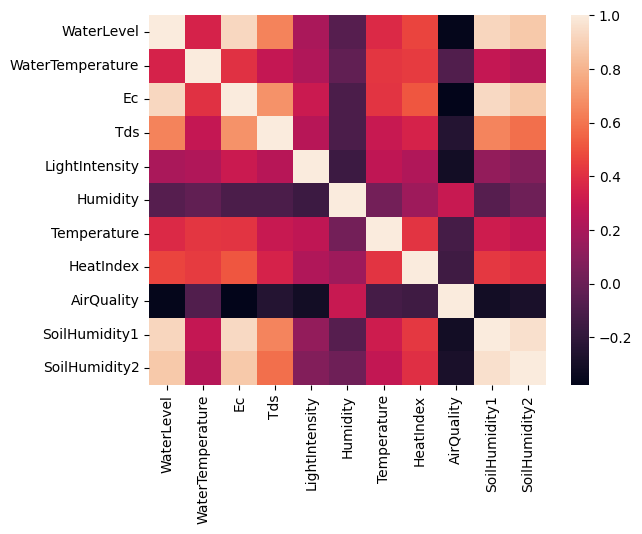

In [23]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True))

In [24]:
import numpy as np

corr_matrix = df.corr(numeric_only=True)

corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print(corr_pairs.head(10)) # here we are taking the top 10 pairs of features with the highest correlation values. You can adjust this number as needed.

SoilHumidity1  SoilHumidity2    0.957984
Ec             SoilHumidity1    0.932932
WaterLevel     Ec               0.928922
               SoilHumidity1    0.923320
Ec             SoilHumidity2    0.871768
WaterLevel     SoilHumidity2    0.871070
Ec             Tds              0.691240
Tds            SoilHumidity1    0.645758
WaterLevel     Tds              0.641521
Tds            SoilHumidity2    0.583235
dtype: float64


Conclustion about this correlation : 

Correlation analysis demonstrated strong positive relationships among the irrigation, nutrient, and soil moisture parameters. The strongest correlation was observed between SoilHumidity1 and SoilHumidity2 (r = 0.958), indicating highly similar moisture measurements across sensor locations. WaterLevel exhibited strong positive correlations with EC (r = 0.929), SoilHumidity1 (r = 0.923), and SoilHumidity2 (r = 0.871), suggesting that water availability plays a crucial role in maintaining soil moisture and nutrient concentration. These findings confirm the interconnected nature of water management and soil conditions in the smart agriculture system and provide valuable insights for feature selection and predictive modeling.

In [25]:
df.nunique()

Timestamp            172800
WaterLevel               19
WaterPumpToTank           2
WaterPumpFromTank         2
WaterTemperature         52
Ec                       37
Tds                      38
LightIntensity         1949
Humidity                199
Temperature              36
HeatIndex               294
AirQuality              297
SoilHumidity1           290
SoilHumidity2           436
Light                     2
Class                     2
dtype: int64

In [26]:
df.var(numeric_only=True)

WaterLevel              27.041939
WaterTemperature         1.873981
Ec                    7338.759353
Tds                   2362.914123
LightIntensity      121659.835538
Humidity                25.321356
Temperature              1.929563
HeatIndex                1.804993
AirQuality            3250.260390
SoilHumidity1           43.571343
SoilHumidity2           57.081438
dtype: float64

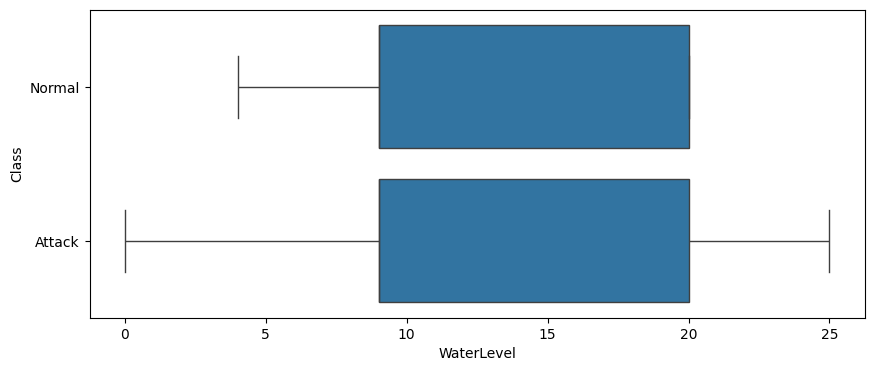

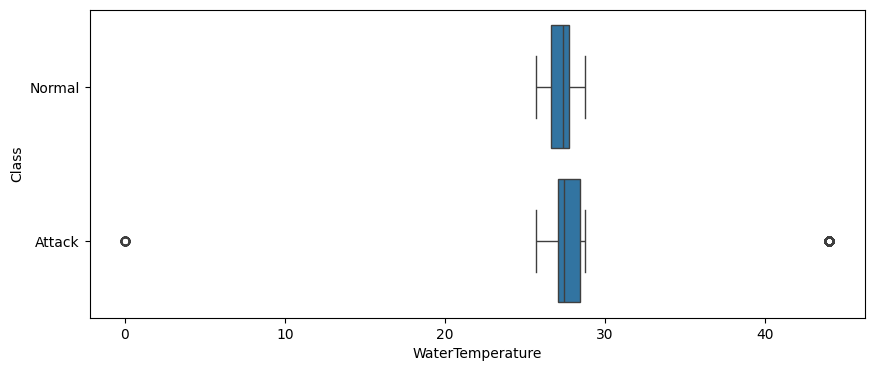

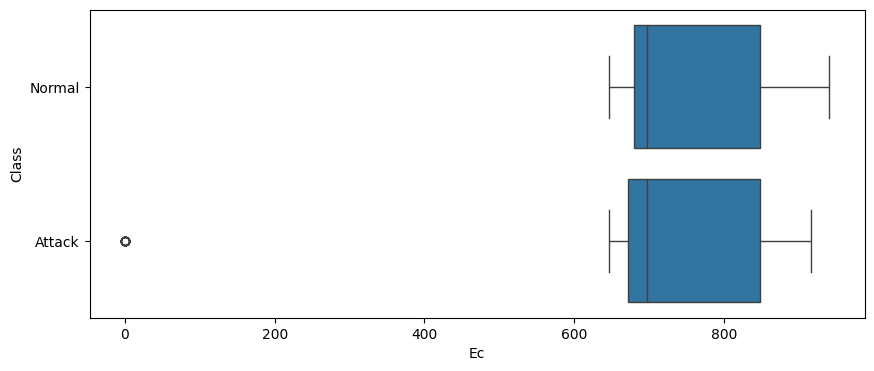

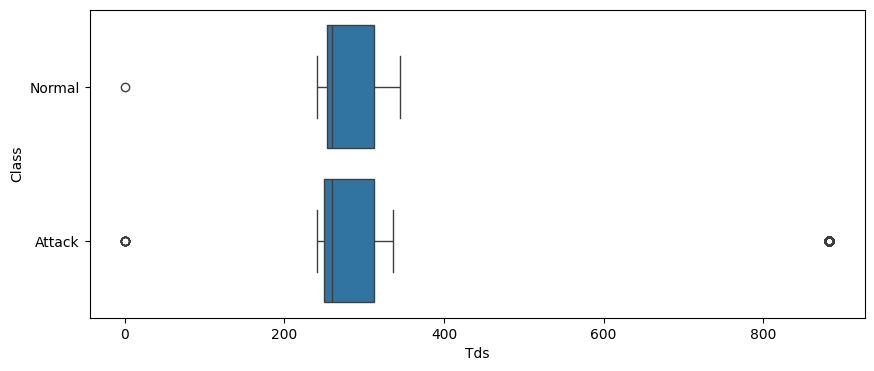

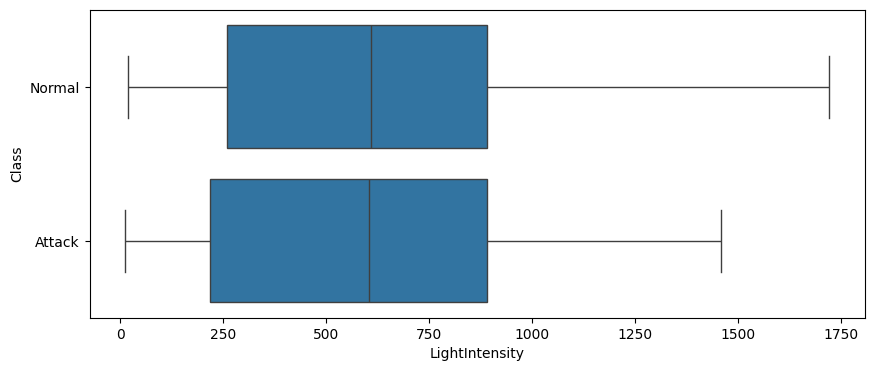

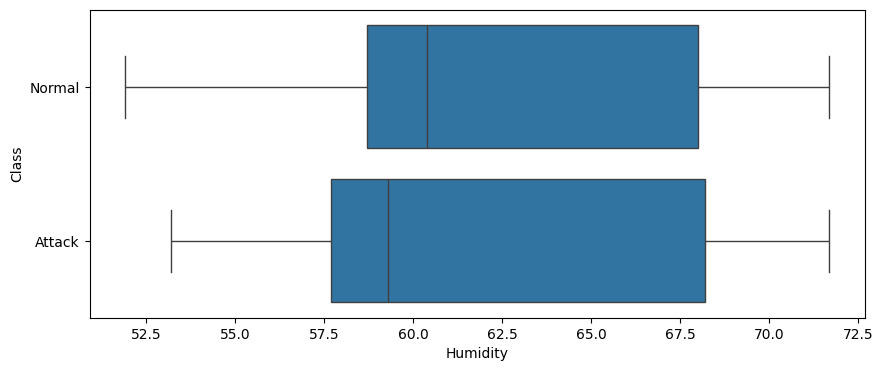

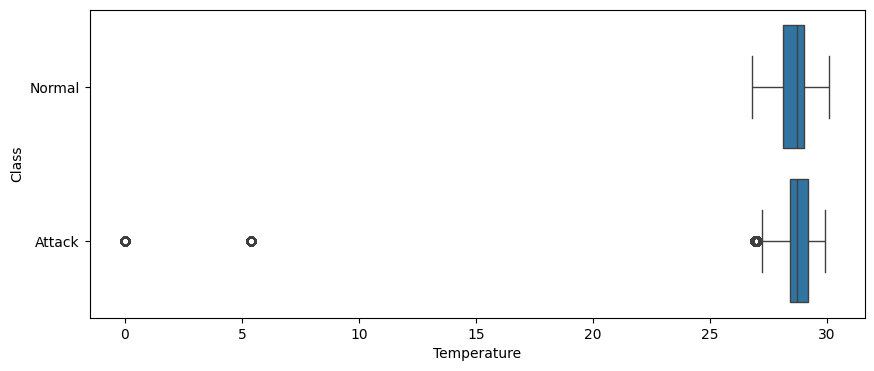

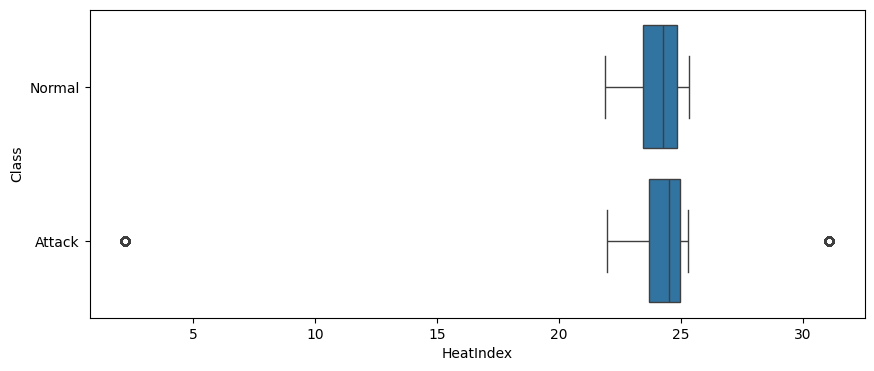

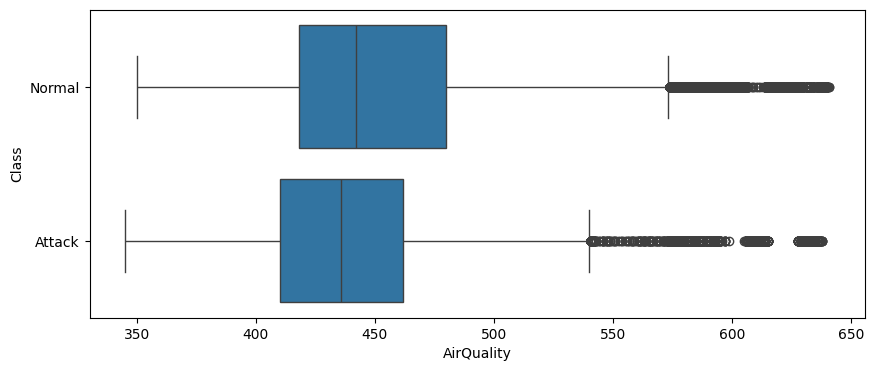

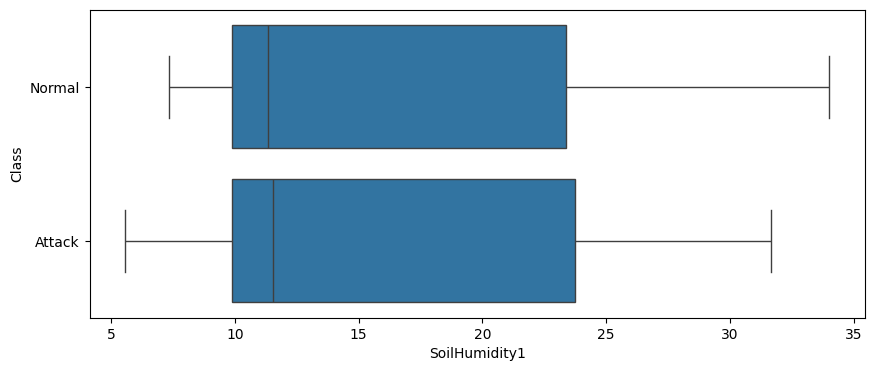

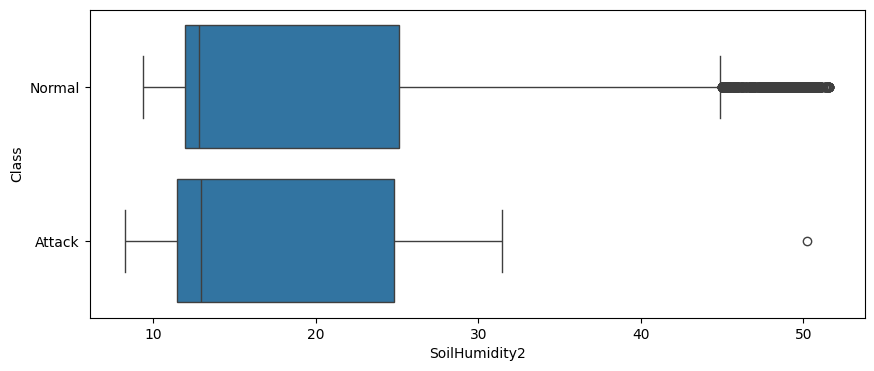

In [27]:
for i in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[i], y=df['Class'])

In [28]:
categorical_cols = ['WaterPumpToTank', 'WaterPumpFromTank', 'Light', 'Class']

In [29]:
categorical_cols

['WaterPumpToTank', 'WaterPumpFromTank', 'Light', 'Class']

In [ ]:
df[numeric_cols].kurtosis()

WaterLevel           -1.226203
WaterTemperature    103.724745
Ec                   -0.614030
Tds                  93.406144
LightIntensity       -0.271128
Humidity             -1.095421
Temperature         232.565327
HeatIndex            88.733521
AirQuality            0.462888
SoilHumidity1        -1.182413
SoilHumidity2         0.394445
dtype: float64

In [ ]:
print(df[categorical_cols].nunique())

WaterPumpToTank      2
WaterPumpFromTank    2
Light                2
Class                2
dtype: int64


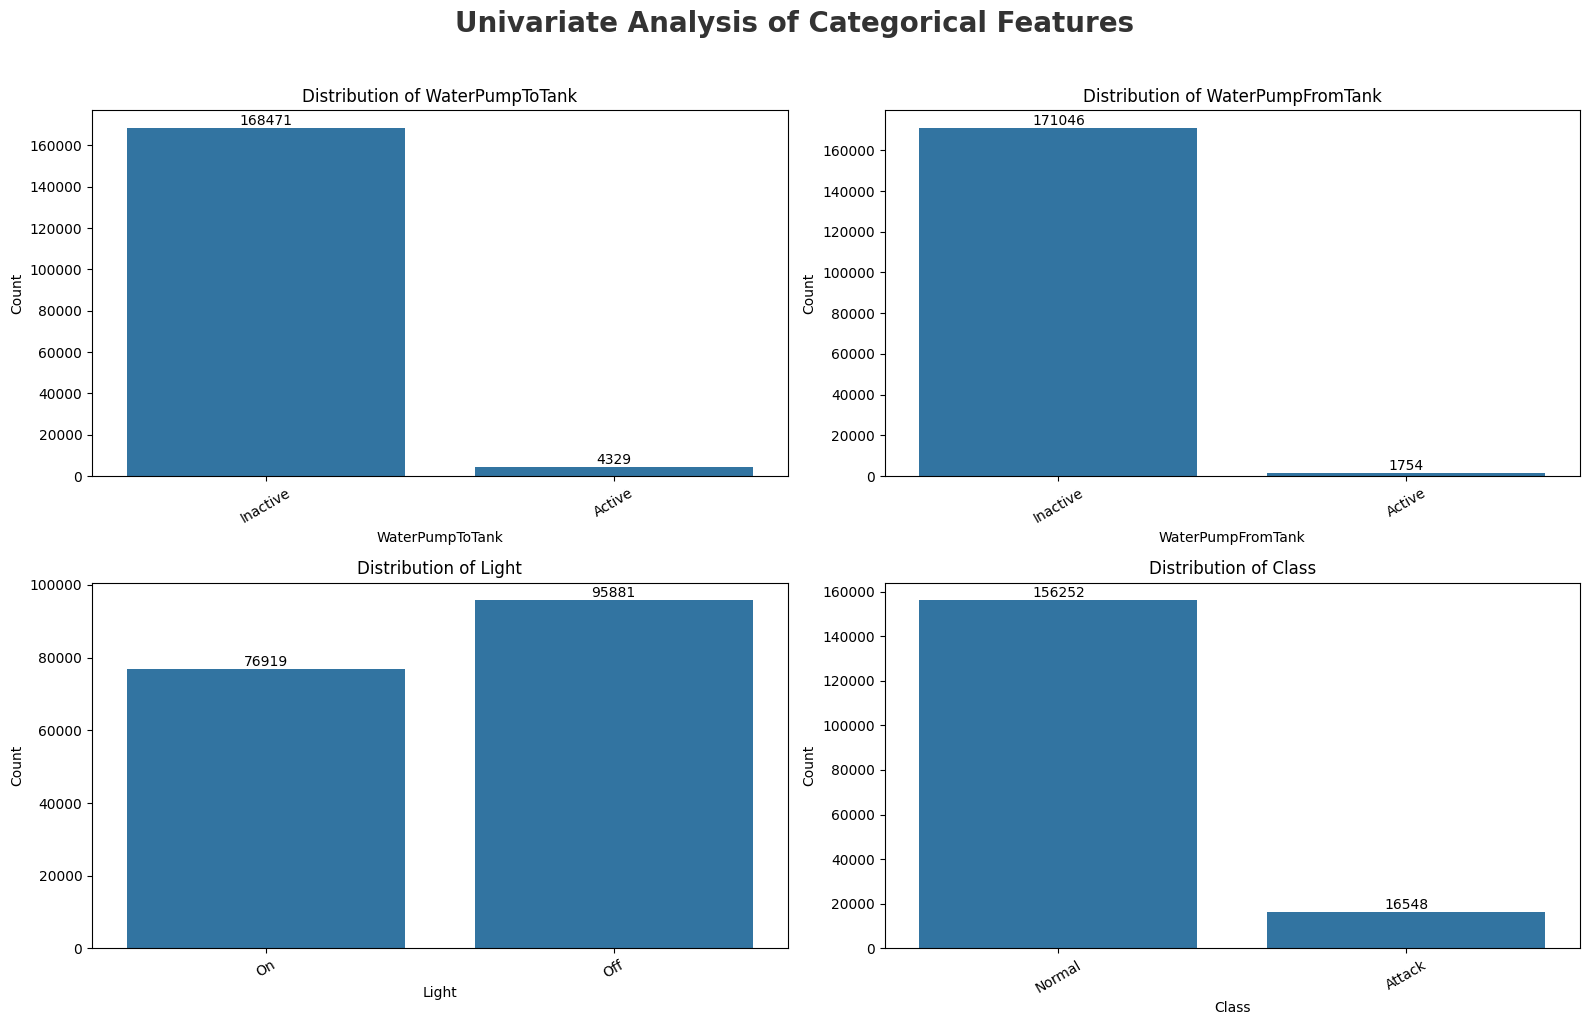

In [33]:
# 1. Check if there are any categorical columns to plot
if not categorical_cols:
    print("No categorical columns to plot.")
else:
    n_features = len(categorical_cols)
    n_cols = 2
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    fig.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.02)
    
    # 2. Use .flatten() to make it 1D, handling cases with 1 row or multiple rows
    # (If n_features==1, plt.subplots might return just a single axis or a 1D array, 
    # so converting to np.array first ensures .flatten() works universally)
    axes = np.array(axes).flatten() 
    
    for ax, feature in zip(axes, categorical_cols):
        # 3. Preferred seaborn syntax
        sns.countplot(data=df, x=feature, ax=ax)
        
        ax.set_xlabel(feature)
        ax.set_ylabel('Count')
        ax.set_title(f'Distribution of {feature}')
        ax.tick_params(axis='x', rotation=30)

        # Add value labels on top of bars
        if df[feature].nunique() < 10:
            for patch in ax.patches:
                # Get height (count)
                height = patch.get_height()
                # Sometimes height can be NaN if the bar is empty, so we can handle that safely
                if not np.isnan(height) and height > 0:
                    ax.annotate(f'{height:.0f}', 
                                (patch.get_x() + patch.get_width() / 2, height),
                                ha='center', va='bottom', fontsize=10)

    # Hide any unused subplots
    for ax in axes[n_features:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


Univariate Analysis of Categorical Features

The categorical feature analysis reveals that most operational states in the smart agriculture system are highly imbalanced.

WaterPumpToTank

The WaterPumpToTank feature is predominantly in the Inactive state, with 168,471 observations (97.49%), while the Active state occurs only 4,329 times (2.51%).

Conclusion:
The pump responsible for filling the tank remains inactive for most of the monitoring period, indicating that tank refilling is an infrequent event.

WaterPumpFromTank

The WaterPumpFromTank feature is also heavily dominated by the Inactive state, with 171,046 observations (98.98%), compared to only 1,754 Active observations (1.02%).

Conclusion:
The irrigation pump is active only occasionally, suggesting that water distribution events occur during specific periods rather than continuously.

Light

The Light feature shows a relatively balanced distribution compared to the pump features, with 95,881 observations (55.49%) in the Off state and 76,919 observations (44.51%) in the On state.

Conclusion:
The artificial lighting system alternates regularly between ON and OFF states, reflecting normal operational cycles in the agricultural environment.

Class (Target Variable)

The target variable consists of 156,252 Normal observations (90.42%) and 16,548 Attack observations (9.58%).

Conclusion:
The dataset exhibits a noticeable class imbalance, with Normal events significantly outnumbering Attack events. This imbalance may bias machine learning models toward the majority class and should be considered during model evaluation and training.

Overall Conclusion

The categorical analysis indicates that both water pump systems operate only during limited periods, resulting in highly imbalanced operational states. The lighting system exhibits a more balanced distribution, suggesting regular switching behavior. The target variable is moderately imbalanced, with approximately 90% Normal and 10% Attack instances. These findings suggest that categorical features should be carefully evaluated for predictive relevance, and appropriate techniques such as class weighting or imbalance-aware evaluation metrics should be used during model development.

Research-Level Observation

The extreme imbalance in:

WaterPumpToTank (97.49% Inactive)
WaterPumpFromTank (98.98% Inactive)

raises an important question:

Are pump activation events associated with attack occurrences?

C:\Users\rohit\AppData\Local\Temp\ipykernel_22676\3819618743.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=feature, palette='Set2')
C:\Users\rohit\AppData\Local\Temp\ipykernel_22676\3819618743.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=feature, palette='Set2')
C:\Users\rohit\AppData\Local\Temp\ipykernel_22676\3819618743.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=feature, palette='Set2')
C:\Users\rohit\AppData\Local\Temp\ipykernel_22676\3819618743.py:8: 

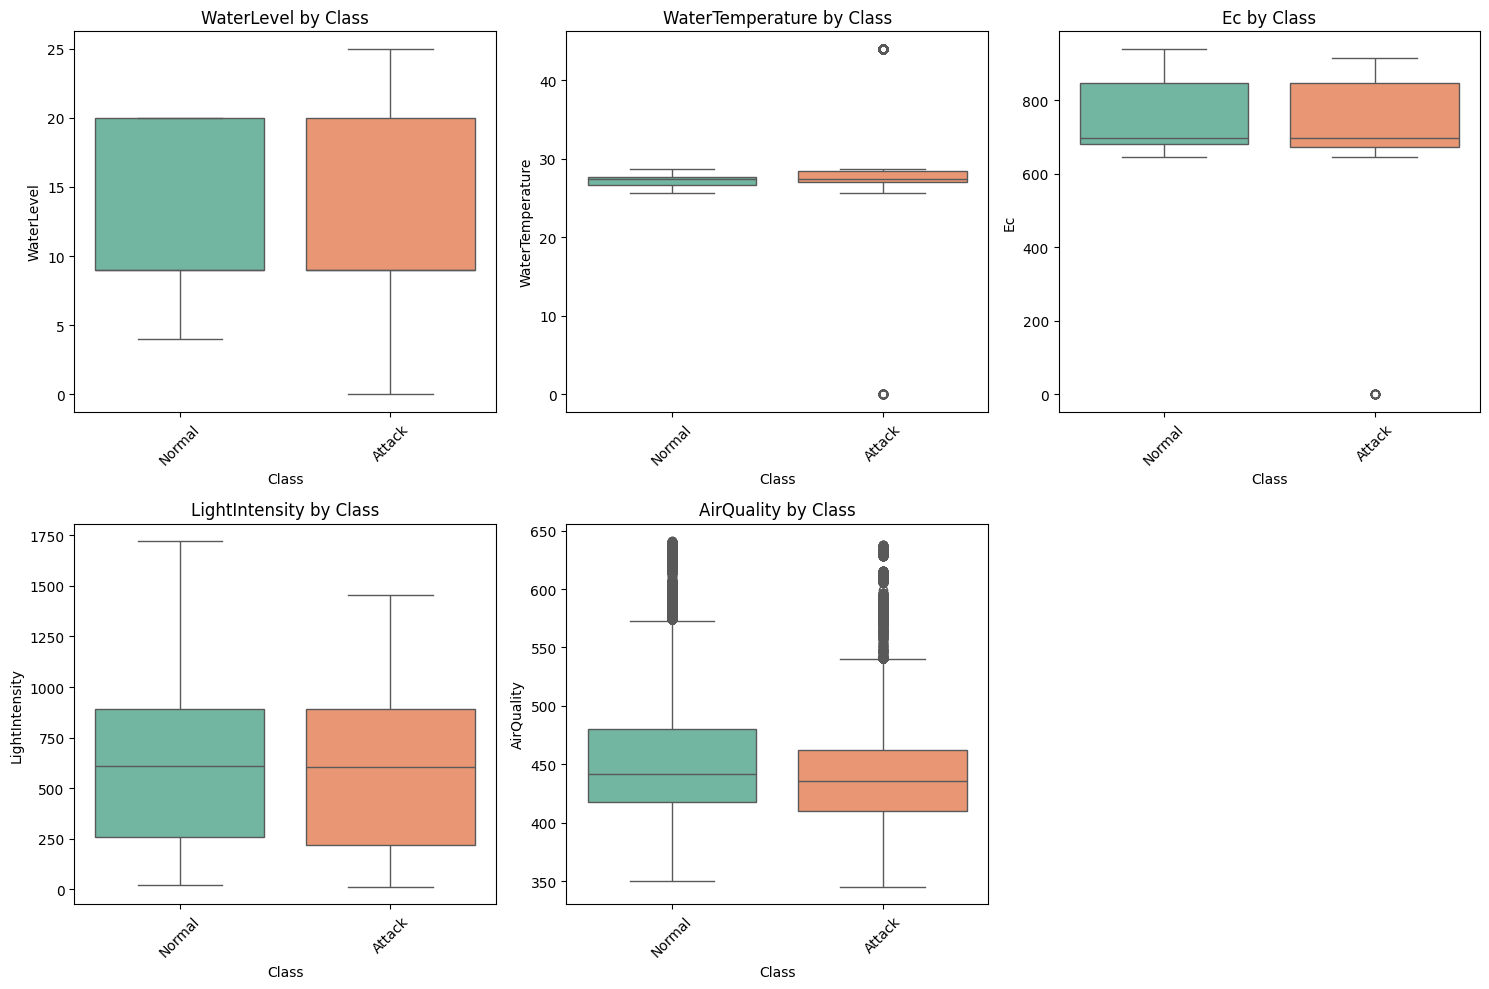

In [ ]:
features_to_plot = ['WaterLevel', 'WaterTemperature', 'Ec', 'LightIntensity', 'AirQuality']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='Class', y=feature, palette='Set2')
    plt.title(f'{feature} by Class')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


WaterLevel by Class
Observation
Median values are almost identical.
IQR (box size) is very similar.
Strong overlap between Normal and Attack.
Conclusion

WaterLevel does not show a substantial difference between Normal and Attack classes. As a standalone feature, it may have limited discriminative power for attack detection.

WaterTemperature by Class
Observation
Median values are very close.
Attack class contains extreme outliers (0°C and 44°C).
Majority of observations overlap.
Conclusion

WaterTemperature exhibits similar central tendencies across both classes; however, attack records contain several anomalous temperature readings, suggesting that extreme temperature values may be associated with abnormal system behavior.

🚩 Attack class contains notable anomalies.

EC by Class
Observation
Similar median values.
Similar spread.
Attack class contains a zero-value outlier.
Conclusion

EC distributions are largely similar between Normal and Attack classes. However, abnormal low EC values are observed in the Attack class, indicating potential sensor anomalies or malicious manipulation.

LightIntensity by Class
Observation
Medians are almost identical.
Large overlap between classes.
Similar variability.
Conclusion

LightIntensity alone does not appear to clearly separate Normal and Attack observations, suggesting limited predictive capability as an individual feature.

AirQuality by Class
Observation
Attack class median is slightly lower.
Distributions overlap heavily.
Both classes contain upper-end outliers.
Conclusion

AirQuality shows a slight shift between Normal and Attack classes, but the substantial overlap suggests that it is unlikely to serve as a strong standalone indicator of attacks.

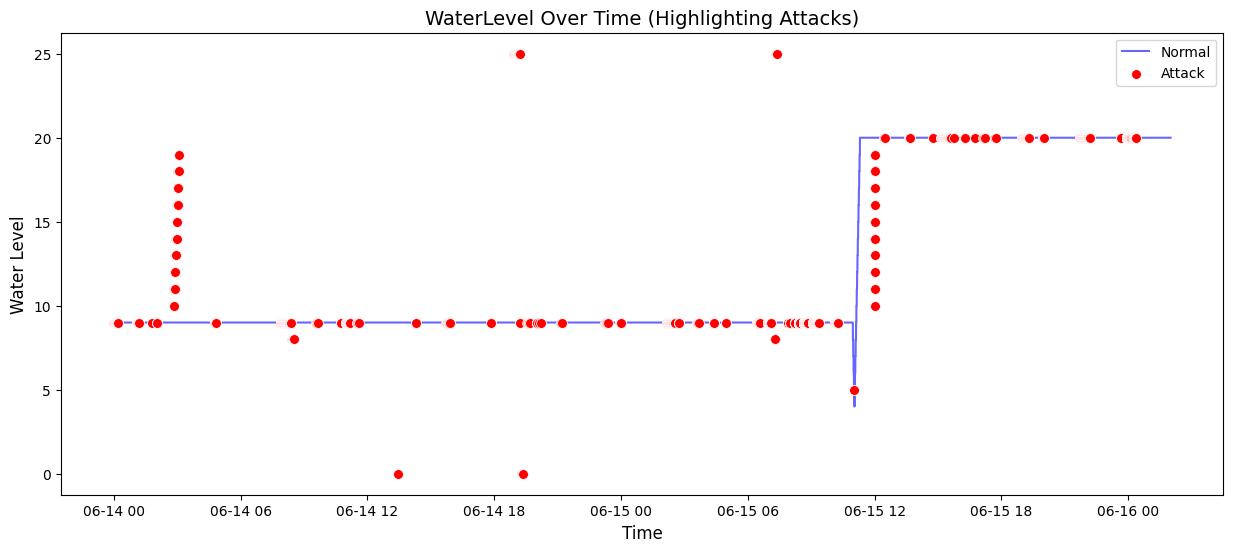

In [44]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d.%m.%Y %H:%M:%S')

df = df.sort_values('Timestamp')

plt.figure(figsize=(15, 6))

sns.lineplot(data=df[df['Class'] == 'Normal'], x='Timestamp', y='WaterLevel', 
             label='Normal', color='blue', alpha=0.6)

sns.scatterplot(data=df[df['Class'] != 'Normal'], x='Timestamp', y='WaterLevel', 
                label='Attack', color='red', s=50, zorder=5)

plt.title('WaterLevel Over Time (Highlighting Attacks)', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Water Level', fontsize=12)
plt.legend()
plt.show()



### Conclusion of Temporal Water Level Analysis:
The time-series plot reveals a very clear and distinct pattern regarding how cyberattacks interact with the `WaterLevel` sensor readings:

1. **Extreme Sensor Volatility During Attacks:** During normal operations (blue line), the water level remains incredibly stable, staying completely flat at 9 for a long period, and later shifting to a stable 20. However, when an attack occurs (red dots), the sensor readings become highly erratic, showing sudden and extreme vertical spikes (e.g., dropping straight to 0 or jumping to 25).
2. **Artificial Anomalies:** The vertical "stacking" of red dots at specific timestamps indicates that the attacker is likely injecting rapid, artificial fluctuations into the sensor data rather than causing a slow, physical drain or fill of the water tank. 
3. **Strong Predictive Feature:** Because the attacks cause the water level reading to deviate so drastically from the stable baseline, `WaterLevel` is a highly sensitive and strong feature for our machine learning model to detect anomalies.


C:\Users\rohit\AppData\Local\Temp\ipykernel_22676\3752866346.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['Class'] != 'Normal'], x='Hour', palette='Reds')


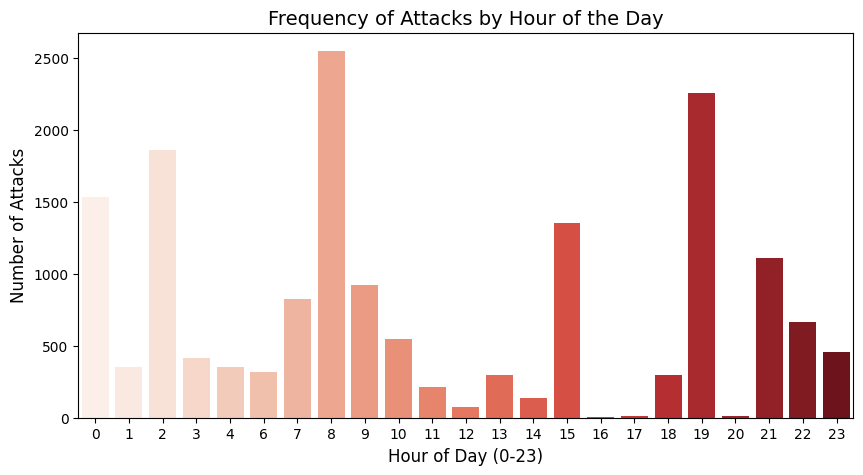

In [43]:
df['Hour'] = df['Timestamp'].dt.hour

plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['Class'] != 'Normal'], x='Hour', palette='Reds')
plt.title('Frequency of Attacks by Hour of the Day', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.show()


### Conclusion of Temporal "Time of Day" Analysis:
The distribution of attacks throughout the day reveals strong temporal patterns, indicating that the cyberattacks are not occurring randomly:

1. **High-Risk Hours:** The vast majority of attacks cluster around specific times of the day. The most significant peak occurs at 8:00 AM (over 2,500 attacks), followed by another massive spike at 7:00 PM (19:00, over 2,200 attacks). There are also notable secondary peaks around midnight (0:00) and 2:00 AM.
2. **Low-Risk Hours:** Conversely, there are periods where attacks are nearly non-existent, such as 4:00 PM (16:00), 5:00 PM (17:00), and 8:00 PM (20:00). Wait, notably, hour 5 is entirely missing from the attack data in this plot.
3. **Feature Engineering Value:** Because the attack frequency varies so wildly depending on the hour, the engineered `Hour` feature captures a powerful, hidden pattern. The machine learning model will be able to heavily weigh the time of day when deciding if a set of sensor readings represents an attack.
